In [268]:
import numpy as np
import pandas as pd
import cv2
import os
from pathlib import Path
from collections import Counter

import torch
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dropout, Flatten, Dense, Layer, BatchNormalization
from tensorflow.keras.models import Sequential
#from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.preprocessing.image import load_img
from keras.src.legacy.preprocessing.image import ImageDataGenerator


import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

import warnings
warnings.filterwarnings('ignore')

In [269]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device.type}")

Using device: cpu


In [270]:
def check_folder(data_path):
    """
    Функция возвращает данные о содержимом папки
    :param data_path: folder path
    """
    folder = Path(data_path)
    
    total_files = 0
    total_folders = 0
    total_size = 0
    extensions = []
    
    for item in folder.rglob('*'):  # рекурсивно пройдем по всем вложенным файлам и папкам
        if item.is_file():
            total_files += 1
            total_size += item.stat().st_size
            ext = item.suffix.lower() if item.suffix else 'без расширения'
            extensions.append(ext)
        elif item.is_dir():
            total_folders += 1
    
    ext_counts = Counter(extensions)
    
    folder_stats = (total_files, total_folders, total_size)
    
    print(f"Статистика папки: {data_path}")
    print(f"Всего файлов: {total_files}")
    print(f"Всего папок (включая вложенные): {total_folders}")
    print(f"Общий размер файлов: {total_size / (1024**2):.2f} МБ")
    print("\nРаспределение по расширениям файлов:")
    for ext, count in ext_counts.most_common():
        print(f"  {ext}: {count}")
    return folder_stats

In [271]:
data_path = os.path.join(str(Path.home()), 'PycharmProjects/ML/src/data', 'animals')
if not os.path.exists(data_path):
    os.makedirs(data_path)

в этот раз, для разнообразия, используем для загрузки данных API. Короткая напоминалка, чтобы всё получилось:
1. Создайте (или скачайте) файл `kaggle.json`
	* Перейдите в ваш аккаунт Kaggle: https://www.kaggle.com/
	* Нажмите на ваш профиль → “Account” (Аккаунт)
	* В разделе “API” нажмите “Create New API Token” 
2. Поместите файл `kaggle.json` в нужное место
	* Переместите скачанный файл в папку /Users/aleksandrkoval/.kaggle/
3. Задать нужные права на файл
    * chmod 600 kaggle.json

In [272]:
from kaggle.api.kaggle_api_extended import KaggleApi

folder_stats = check_folder(data_path)
if folder_stats[2] == 0:
    api = KaggleApi()
    api.authenticate()
    api.dataset_download_files("andrewmvd/animal-faces", path=data_path, unzip=True)
    print("\nЗагрузка завершена")
else:  print("\nПапка не пустая")

Статистика папки: /Users/aleksandrkoval/PycharmProjects/ML/src/data/animals
Всего файлов: 16134
Всего папок (включая вложенные): 9
Общий размер файлов: 695.59 МБ

Распределение по расширениям файлов:
  .jpg: 16130
  без расширения: 4

Папка не пустая


In [273]:
data_train = os.path.join(data_path, 'afhq/train/')
data_val = os.path.join(data_path, 'afhq/val/')

In [274]:
def get_animals_data(classes, data_path):
    """
    возвращает DataFrame, содержащий путь к картинке и класс животного
    :param classes: classes of animals
    :param data_path: path of data
    """
    allPics = []
    allAnimals = []
    for classElement in classes:
        filenames = os.listdir(os.path.join(data_path, classElement))
        for file in filenames:
            file_name = os.path.join(classElement, file)
            allPics.append(file_name)
        allAnimals.extend([classes[classElement]] * len(filenames))
    
    df = pd.DataFrame({
        'filename': allPics,
        'class': allAnimals
    })
    return df

In [275]:
classes = {"cat": "0", "dog": "1", "wild": "2"}
df_train = get_animals_data(classes, data_train)
df_test = get_animals_data(classes, data_val)
print("df_test:", df_test.shape) 
display(df_test.head())

df_test: (1500, 2)


,filename,class
0,cat/pixabay_cat_002256.jpg,0
1,cat/pixabay_cat_000441.jpg,0
2,cat/flickr_cat_000802.jpg,0
3,cat/flickr_cat_000816.jpg,0
4,cat/flickr_cat_000180.jpg,0


In [276]:
def show_images(path, df, title="Image", cols=3, cmap=None):
    """
    выводит заданное количество картинок для каждого класса животных
    :param path: path to folder
    :param df: dataframe
    :param title: title
    :param cols: number of pics to show
    :param cmap: color map
    """
    filter_val = []
    filter_val = df.groupby('class').head(cols)
    img_list = list(os.path.join(path,filename) for filename in filter_val['filename'].to_list())
    print(len(img_list))
    plt.figure(figsize=(cols*3, cols*9/5), dpi=300)
    if cols*3 > len(img_list): cols = len(img_list)
    for i, img_p in enumerate(img_list):
        plt.subplot(1, cols*3, i+1)
        img = cv2.imread(img_p)
        if len(img.shape) == 2:
            plt.imshow(img, cmap=cmap or "gray")
        else:
            plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.title(f"{title} {i+1}")
        #if i == cols*3 - 1: break
    plt.show()

12


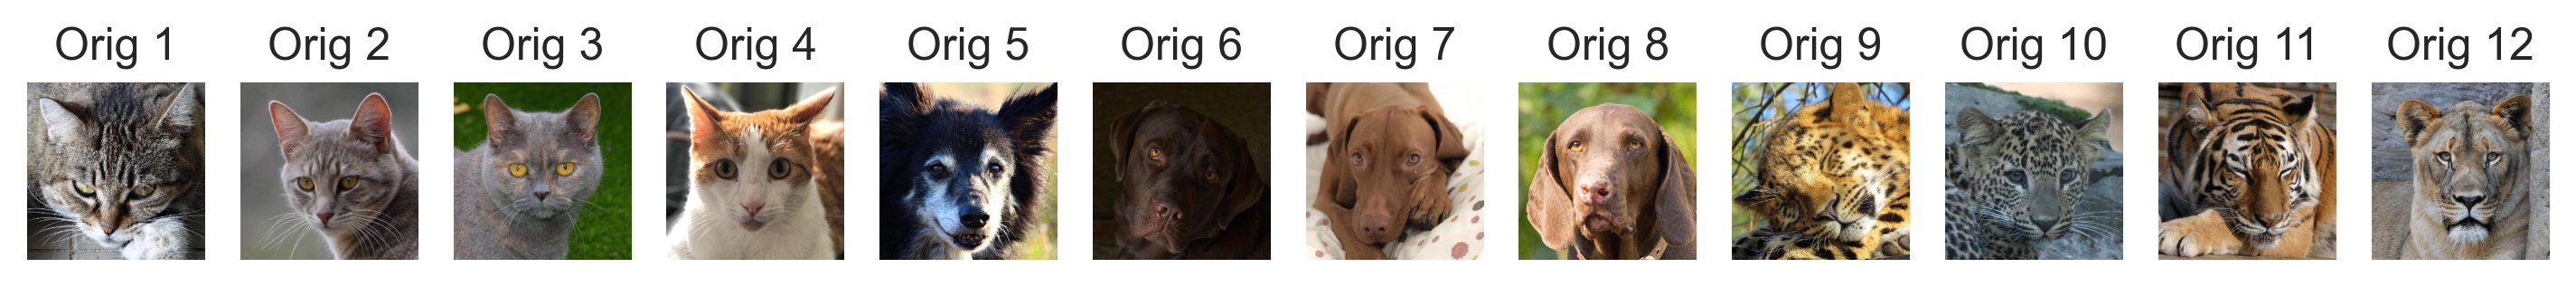

In [277]:
show_images(data_val, df_test, "Orig", 4) 
# путь, датафрейм, подпись, количество картинок из каждого вида

12


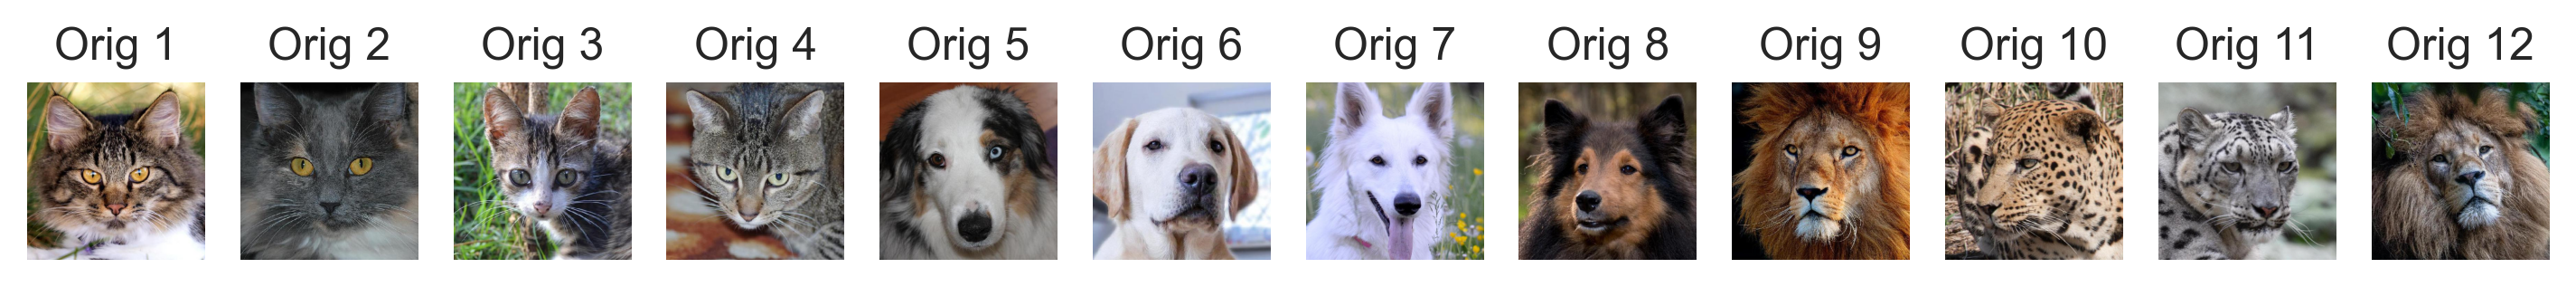

In [278]:
show_images(data_train, df_train, "Orig", 4)

Подготовка данных

In [301]:
df_training, df_testing = train_test_split(df_train, test_size = 0.20)
df_training = df_training.reset_index(drop = True)
df_testing = df_testing.reset_index(drop = True)

In [302]:
df_training[:5]

,filename,class
0,dog/flickr_dog_000329.jpg,1
1,cat/pixabay_cat_002083.jpg,0
2,cat/pixabay_cat_000728.jpg,0
3,dog/flickr_dog_000260.jpg,1
4,dog/pixabay_dog_003712.jpg,1


Расширение обучающих данных:
* Диапазон поворота: 20°
* Диапазон изменения ширины/высоты: 0,2
* Диапазон сдвига: 0,2
* Диапазон масштабирования: 0,2
* Горизонтальный сдвиг: включен
* Режим заливки: Ближайший сосед

In [303]:
IMG_SIZE = 100
batch_size = 32

In [304]:
cnn_train_datagen = ImageDataGenerator(
    rotation_range = 45,
    width_shift_range = 0.2,  
    height_shift_range = 0.2,    
    zoom_range = 0.2,        
    horizontal_flip = True, 
    rescale = 1./255,
    validation_split=0.2,
    fill_mode = 'nearest'
)

cnn_test_datagen = ImageDataGenerator(
    rotation_range = 45,
    width_shift_range = 0.2,  
    height_shift_range = 0.2,    
    zoom_range = 0.2,        
    horizontal_flip = True, 
    rescale = 1./255,
    validation_split=0.2,
    fill_mode = 'nearest'
)

In [305]:
cnn_train_generator = cnn_train_datagen.flow_from_dataframe(
        dataframe=df_training,
        directory = data_train,
        target_size=(IMG_SIZE,IMG_SIZE),
        x_col = 'filename',
        y_col = 'class',
        batch_size=batch_size,
        class_mode='categorical',
        subset='training'
)

cnn_test_generator = cnn_test_datagen.flow_from_dataframe(
        dataframe=df_testing,
        directory = data_train,
        target_size=(IMG_SIZE,IMG_SIZE),
        x_col = 'filename',
        y_col = 'class',
        batch_size=batch_size,
        class_mode='categorical',
        subset='training'
)

Found 9364 validated image filenames belonging to 3 classes.
Found 2341 validated image filenames belonging to 3 classes.


Found 1 validated image filenames belonging to 1 classes.


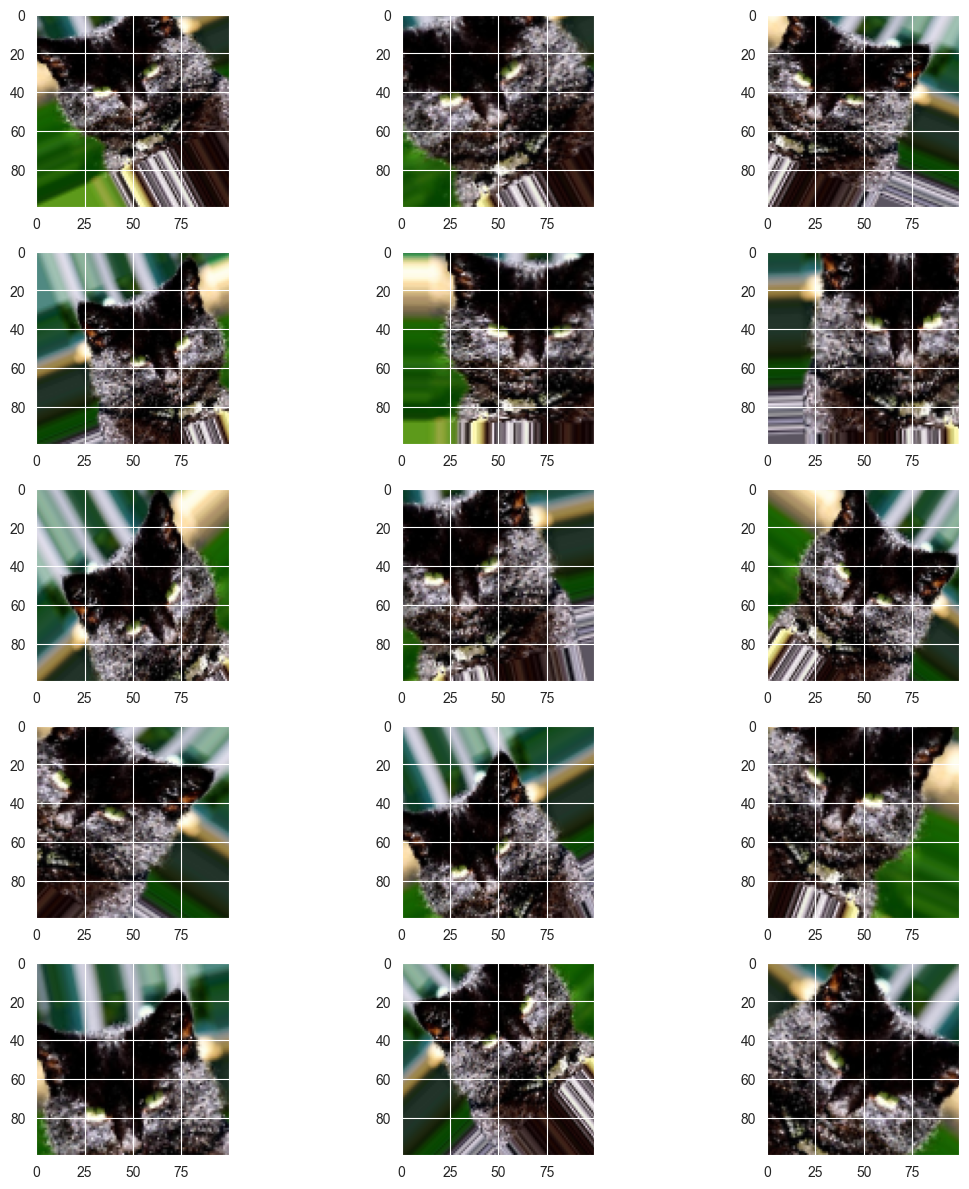

In [306]:
# посмотрим, как будет выглядеть преобразование изображений на одном примере

df_example = df_training.sample(n=1).reset_index(drop=True)
example_generator = cnn_train_datagen.flow_from_dataframe(
    dataframe= df_example, 
    directory= data_train, 
    x_col='filename',
    y_col='class',
    target_size = (IMG_SIZE,IMG_SIZE),
    class_mode='categorical',
    subset='training'
)

plt.figure(figsize=(12, 12))
for i in range(0, 15):
    plt.subplot(5, 3, i+1)
    for X_batch, Y_batch in example_generator:
        image = X_batch[0]
        plt.imshow(image)
        break
plt.tight_layout()
plt.show()

In [297]:
cnn_train_generator.class_indices

{'0': 0, '1': 1, '2': 2}

In [307]:
cnn_model = keras.Sequential([ # создадим свёрточную сеть
    keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)), # первый слой на входе сети
 # запустим несколько последовательных слоёв с последовательным увеличением количества фильтров 32-64-128-256-256-512. Это обеспечивает последовательное обучение более абстрактных блоков, начиная с более простых.

    keras.layers.Conv2D(32, (3, 3), activation='relu', padding='same'), #свёрточный слой, извлекающий признаки из изображения
    keras.layers.BatchNormalization(), # нормализация активаций в батче для ускорения и стабилизации обучения. 
    keras.layers.MaxPooling2D((2, 2)), # операция подвыборки, уменьшает размерность карты признаков в 2 раза по ширине и высоте
    keras.layers.Dropout(0.2), # регуляризация, случайно исключаем 20% нейронов для предотвращения переобучения.    
    
    keras.layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.2),


    keras.layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.2),
    
    keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.2),

    keras.layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.2),
    
    keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.2),

    keras.layers.Conv2D(512, (3, 3), activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.2),
    
    keras.layers.Conv2D(1024, (3, 3), activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.2),
    
    keras.layers.Conv2D(1024, (3, 3), activation='relu', padding='same'),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D((2, 2)),
    keras.layers.Dropout(0.2),    

    keras.layers.GlobalAveragePooling2D(),# превращает 3D-тензор из сверточной части в 1D-вектор, чтобы подключить полностью связанные слои
    keras.layers.Dropout(0.5), 
    keras.layers.Dense(256, activation='relu', kernel_regularizer=keras.regularizers.l2(1e-4)), # используем L2 регуляризацию для 
    keras.layers.Dropout(0.4),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(units=len(cnn_test_generator.class_indices), activation='softmax')

])

In [ ]:
def conv_block(x, filters, kernel_size=(3,3), dropout_rate=0.2):
    x = Conv2D(filters, kernel_size, padding='same',
               kernel_regularizer=regularizers.l2(1e-4))(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = MaxPooling2D((2,2))(x)
    x = Dropout(dropout_rate)(x)
    return x

In [308]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 100, 100, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 100, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 50, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 25, 25, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 6, 6, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 6, 6, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,327,619 (12.69 MB)

 Trainable params: 3,324,675 (12.68 MB)

 Non-trainable params: 2,944 (11.50 KB)